# **Atividade Prática**
<font size=3>

- **Tema:** métodos probabilísticos.
- **Prazo de entrega:** 07 de Maio.

**Envie** o notebook **executado** em formato **ipynb** pelo [formulário](https://docs.google.com/forms/d/e/1FAIpQLSeHK5qrS-_wttHK6XXKBK2-SXv1nxU3Xhk8x__eP1ZrHulHDw/viewform?usp=header).

---

### **1. Questão:** 
<font size=3>

Com base no *dataset* de [Cogumelos](https://www.kaggle.com/datasets/uciml/mushroom-classification), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:
1. Avalie qual tipo de método **_Naive Bayes_** é mais apropriado para realizar a tarefa de classificação dos dados (ver **_notebook_ 9**). **Justifique** sua resposta em uma **célula _markdown_**;
2. Utilize as funções [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) e [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável de atributos (`X`) e alvo (`y`). Utilize [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) caso ache necessário;
3. Treine seu modelo com [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) a fim de ajustar seu(s) hiperparâmetro(s);
4. Realize predições e avaliaçãoes do modelo com dados de teste;
5. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
   

#### Categorical NB:
Como mencionando no notebook 09 esse metodo de Naive Bayes é proprio para tarefaz que envolve classicar dados por meios probabilisticos
se tornando o melhor metodo para quando os atributos são categóricos e discretos onde não precisa que sejam exatamente binarios para ele realizar a catalogação mas ele espera que passamos index inteiros diferente do GaussianNB. O CategoricalNB foi projetado especificamente para lidar com variáveis de tipo categórico como cores, comivel, feliz/triste, ou seja onde cada atributo segue uma distribuição categórica própria.

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# from google.colab import drive
# drive.mount('/content/drive') 

dataset = pd.read_csv("/content/drive/MyDrive/5 semestre /Aprendizado de maquina supervisionado/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/mushrooms.csv")
dataset.head()

le = LabelEncoder()
scaler = StandardScaler()
model = CategoricalNB()

x = dataset.drop(columns=["class"])
y = dataset["class"]

y_encoded = le.fit_transform(y) 
x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

preprossamento = OrdinalEncoder()

pipe = Pipeline(steps=[('preprocessor', preprossamento),('model', model)])
pipe

Pipeline(steps=[('preprocessor', OrdinalEncoder()), ('model', CategoricalNB())])

Melhor parâmetro: {'model__alpha': 0.01}
              precision    recall  f1-score   support

           e       0.99      0.99      0.99       842
           p       0.99      0.99      0.99       783

    accuracy                           0.99      1625
   macro avg       0.99      0.99      0.99      1625
weighted avg       0.99      0.99      0.99      1625

Matriz de confusão:
 [[835   7]
 [ 10 773]]
Acurácia: 0.990


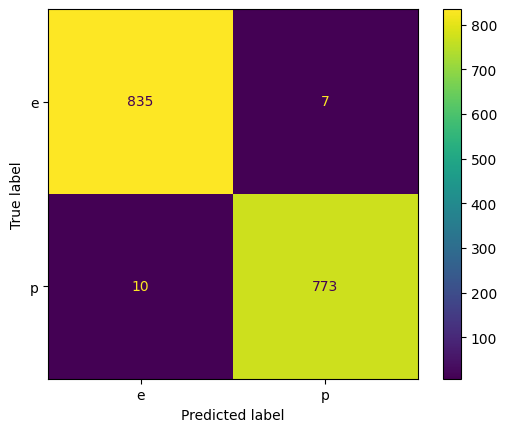

In [5]:
parametros = {
    'model__alpha': [0.01, 0.1, 0.5, 1.0, 10.0]
}

grid = GridSearchCV(pipe, parametros, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)


print(f"Melhor parâmetro: {grid.best_params_}")

y_pred = grid.predict(x_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()


### **2. Questão:** 
<font size=3>

Com base no *dataset* de [Spams](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset), disponível no diretório $\text{dataset/}\,$, realize os seguintes passos:
1. Importe os *dataset* atribuindo à variável `encoding = 'latin-1'` na função `read_csv()`, a fim de importar corretamente os dados textuais;
2. Avalie qual tipo de método **_Naive Bayes_** é mais apropriado para realizar a tarefa de classificação dos dados (ver **_notebook_ 9**). **Justifique** sua resposta em uma **célula _markdown_**;
3. Defina os dados de **_spam_** e **_ham_** (não spam) como a variável alvo, e os dados textuais como a variável de atributos;
4. Utilize o [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) para processar os dados textuais e [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo. Utilize [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) caso ache necessário;
5. Treine seu modelo com [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) a fim de ajustar seu(s) hiperparâmetro(s);
6. Realize predições e avaliaçãoes do modelo com dados de teste;
7. Utilize as funções [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html), [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) e [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) para interpretar os resultados. **Escreva** em uma **cálula _markdown_** sua interpretação quanto ao desempenho das classificações do seu modelo.
    

#### Multinomial NB:

O modelo multinomial por ser probabilistico e lidar de forma robusta com dados do tipo text ele se torna capaz de predictar a natureza do 
email ou de outros textos que passamos como entrada e podemos passa =|CountVectorizer, transformamos o texto em frequências, e o Multinomial NB utiliza essas ocorrências para definir a classe mais provável. por ser capaz de processar de forma menos custosa algotmos e mais eficientes mesmo tendo entradas extramamente grande e com muitos texto.



In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer

dataset = pd.read_csv("/content/drive/MyDrive/5 semestre /Aprendizado de maquina supervisionado/IMD3002 - Aprendizado de Máquina Supervisionado/2-unidade/dataset/spam.csv", encoding= "latin-1")

dataset = dataset.drop(dataset.columns[2:], axis=1)
dataset.columns=["categoria", "texto"]
dataset.head()

model = MultinomialNB()

y = dataset["categoria"]
x = dataset["texto"]

y_encoded = le.fit_transform(y) 

x_train, x_test, y_train, y_test = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

preprossamento = CountVectorizer()

pipe = Pipeline(steps=[
    ('preprocessor', preprossamento),
    ('model', model
     )
])

pipe

Pipeline(steps=[('preprocessor', CountVectorizer()),
                ('model', MultinomialNB())])

Melhor parâmetro: {'model__alpha': 0.5}
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.97      0.93      0.95       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Matriz de confusão:
 [[961   5]
 [ 11 138]]
Acurácia: 0.986


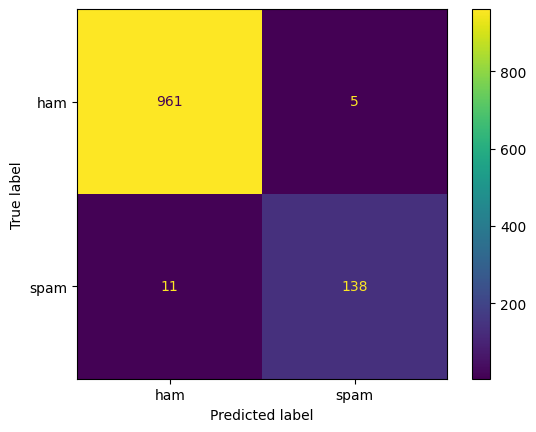

In [26]:
parametros = {
    'model__alpha': [0.01, 0.1, 0.5, 1.0, 10.0]
}


grid = GridSearchCV(pipe, parametros, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)

print(f"Melhor parâmetro: {grid.best_params_}")

y_pred = grid.predict(x_test)
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
